# Klasifikasi Gangguan Fiber Optik Berbasis Data OTDR
## Machine Learning: Random Forest, SVM, Logistic Regression & Soft Voting Ensemble

Notebook ini membangun dan membandingkan empat model machine learning untuk klasifikasi multi-kelas gangguan fiber optik:
1. **Random Forest**
2. **Support Vector Machine (SVM)**
3. **Logistic Regression**
4. **Soft Voting Ensemble** (gabungan RF + SVM + LR)

**Fitur yang digunakan:** `P1`–`P30` (30 titik sinyal OTDR) + `SNR` (Signal-to-Noise Ratio) = **31 fitur**  
**Target:** `Class` (8 kelas gangguan fiber optik)

---
## 1. Import Library

In [1]:
import os
import time
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


---
## 2. Setup Folder Project

Membuat struktur folder otomatis untuk menyimpan data, model, dan laporan.

In [2]:
folders = [
    "data",
    "data/raw",
    "data/processed",
    "models",
    "reports",
    "reports/figures"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Struktur folder berhasil dibuat:")
for folder in folders:
    print(f"  ✅ {folder}/")

Struktur folder berhasil dibuat:
  ✅ data/
  ✅ data/raw/
  ✅ data/processed/
  ✅ models/
  ✅ reports/
  ✅ reports/figures/


---
## 3. Load Dataset

Membaca dataset `OTDR_data.csv` dari beberapa lokasi yang mungkin.

In [3]:
DATA_PATH = "data/raw/OTDR_data.csv"

if not os.path.exists(DATA_PATH):
    DATA_PATH = "OTDR_data.csv"

if not os.path.exists(DATA_PATH):
    DATA_PATH = "/content/OTDR_data.csv"

df = pd.read_csv(DATA_PATH)

print("Shape dataset:", df.shape)
display(df.head())
print(df.info())

Shape dataset: (125832, 36)


,Unnamed: 0,SNR,P1,P2,P3,P4,P5,P6,P7,P8,...,P25,P26,P27,P28,P29,P30,Class,Position,Reflectance,loss
0,70519,10.093627,0.989995,0.769634,0.866942,1.000000,0.838370,0.795462,0.801609,0.763259,...,0.345600,0.114946,0.000000,0.381516,0.099061,0.280784,1.0,0.08,0.0,0.112
1,81009,0.219347,0.341150,0.484929,0.689960,0.924820,0.648481,0.196055,0.886128,1.000000,...,0.384524,0.992029,0.488258,0.402361,0.321495,0.679280,3.0,0.11,0.0,0.400
2,62575,9.282432,0.438344,0.981339,0.728630,0.485106,0.359851,0.184697,0.222956,0.437243,...,0.910126,0.964232,0.637623,0.162285,0.138643,0.723457,0.0,0.00,0.0,0.000
3,70401,8.803449,0.674877,0.638932,0.651814,0.716335,0.475147,0.628348,0.626998,0.691957,...,0.411247,0.097255,0.210350,0.263302,0.132508,0.000000,1.0,0.09,0.0,0.100
4,7550,16.485467,0.767071,0.517559,0.115700,0.000000,0.055019,0.258061,0.115876,0.392273,...,0.457824,0.864551,0.704364,0.508301,0.433237,0.028219,0.0,0.00,0.0,0.000


<class 'pandas.DataFrame'>
RangeIndex: 125832 entries, 0 to 125831
Data columns (total 36 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Unnamed: 0   125832 non-null  int64  
 1   SNR          125832 non-null  float64
 2   P1           125832 non-null  float64
 3   P2           125832 non-null  float64
 4   P3           125832 non-null  float64
 5   P4           125832 non-null  float64
 6   P5           125832 non-null  float64
 7   P6           125832 non-null  float64
 8   P7           125832 non-null  float64
 9   P8           125832 non-null  float64
 10  P9           125832 non-null  float64
 11  P10          125832 non-null  float64
 12  P11          125832 non-null  float64
 13  P12          125832 non-null  float64
 14  P13          125832 non-null  float64
 15  P14          125832 non-null  float64
 16  P15          125832 non-null  float64
 17  P16          125832 non-null  float64
 18  P17          125832 non-null  float

---
## 4. Data Checking

Mengecek kelengkapan kolom, missing value, duplikat, dan distribusi target.

In [4]:
signal_cols = [f"P{i}" for i in range(1, 31)]
extra_cols = ["SNR"]
target_col = "Class"

required_cols = signal_cols + extra_cols + [target_col]
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Kolom berikut tidak ditemukan: {missing_cols}")
else:
    print("✅ Semua kolom wajib tersedia.")

✅ Semua kolom wajib tersedia.


In [5]:
print("Daftar kolom:")
print(df.columns.tolist())

print(f"\nTotal missing value: {df.isna().sum().sum()}")
print(f"Total duplicate: {df.duplicated().sum()}")

print("\nStatistik deskriptif:")
display(df.describe().T)

print("\nDistribusi target Class:")
print(df[target_col].value_counts().sort_index())

Daftar kolom:
['Unnamed: 0', 'SNR', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P19', 'P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30', 'Class', 'Position', 'Reflectance', 'loss']

Total missing value: 0
Total duplicate: 0

Statistik deskriptif:


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,125832.0,62915.500000,36324.713874,0.0,31457.750000,62915.500000,94373.250000,125831.0
SNR,125832.0,12.315957,9.202129,0.0,3.000000,13.000000,20.106899,30.0
P1,125832.0,0.383666,0.343306,0.0,0.041760,0.320210,0.690142,1.0
P2,125832.0,0.379560,0.338766,0.0,0.038821,0.315812,0.685213,1.0
P3,125832.0,0.377179,0.336568,0.0,0.036689,0.310499,0.681227,1.0
P4,125832.0,0.375738,0.332489,0.0,0.040424,0.308350,0.669226,1.0
P5,125832.0,0.376254,0.326922,0.0,0.051494,0.313471,0.660253,1.0
P6,125832.0,0.382815,0.324796,0.0,0.061802,0.333092,0.662213,1.0
P7,125832.0,0.390346,0.319550,0.0,0.079696,0.351876,0.658540,1.0
P8,125832.0,0.399960,0.315327,0.0,0.090327,0.372897,0.664620,1.0



Distribusi target Class:
Class
0.0    16048
1.0    16000
2.0    16000
3.0    16000
4.0    16000
5.0    13849
6.0    16000
7.0    15935
Name: count, dtype: int64


### Analisis Data Checking

Perhatikan hasil di atas:
- Apakah ada missing value yang signifikan?
- Apakah ada duplikat yang perlu dihapus?
- Apakah distribusi kelas seimbang atau imbalanced?

---
## 5. Data Cleaning

Langkah-langkah:
1. Hapus kolom `Unnamed: 0` jika ada
2. Hapus duplikat
3. Konversi fitur menjadi numerik
4. Isi missing value fitur numerik dengan median
5. Hapus baris yang targetnya kosong
6. Mengubah `Class` menjadi integer

In [6]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
    print("✅ Kolom 'Unnamed: 0' dihapus.")

df = df.drop_duplicates()

feature_cols = signal_cols + extra_cols

for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())
df = df.dropna(subset=[target_col])
df[target_col] = df[target_col].astype(int)

print("Shape setelah cleaning:", df.shape)
print("\nDistribusi target setelah cleaning:")
print(df[target_col].value_counts().sort_index())

✅ Kolom 'Unnamed: 0' dihapus.
Shape setelah cleaning: (119008, 35)

Distribusi target setelah cleaning:
Class
0    16044
1    16000
2     9180
3    16000
4    16000
5    13849
6    16000
7    15935
Name: count, dtype: int64


---
## 6. Label Mapping

Memetakan kode kelas numerik ke nama gangguan fiber optik.

In [7]:
label_mapping = {
    0: "Normal",
    1: "Fiber eavesdropping",
    2: "Bad splice",
    3: "Fiber bending",
    4: "Dirty connectors",
    5: "Fiber cut",
    6: "PC connector",
    7: "Reflectors"
}

df["Class_Label"] = df[target_col].map(label_mapping)

print("Label mapping:")
for k, v in label_mapping.items():
    print(f"  {k} → {v}")

Label mapping:
  0 → Normal
  1 → Fiber eavesdropping
  2 → Bad splice
  3 → Fiber bending
  4 → Dirty connectors
  5 → Fiber cut
  6 → PC connector
  7 → Reflectors


---
## 7. Exploratory Data Analysis (EDA)

### 7.1 Distribusi Kelas Fault OTDR

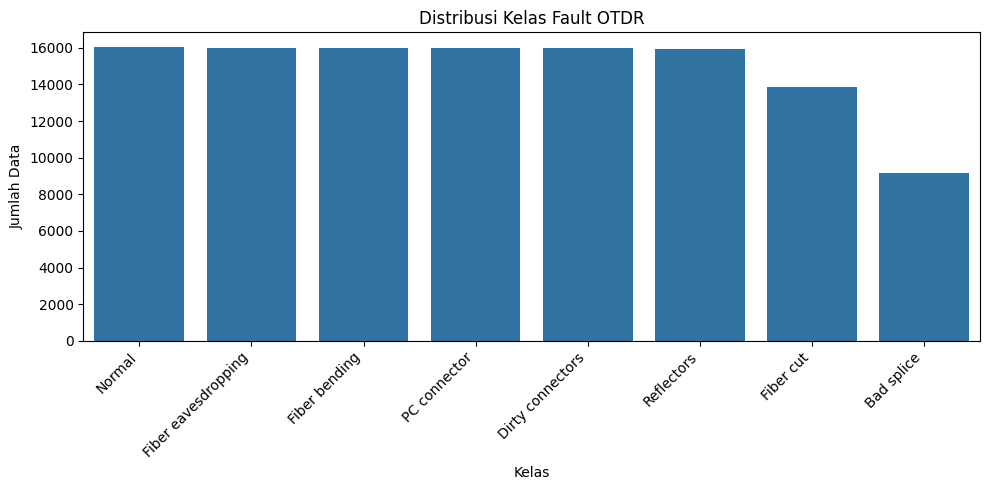

In [8]:
class_counts = df["Class_Label"].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Distribusi Kelas Fault OTDR")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("reports/figures/class_distribution.png", dpi=300)
plt.show()

### 7.2 Distribusi SNR

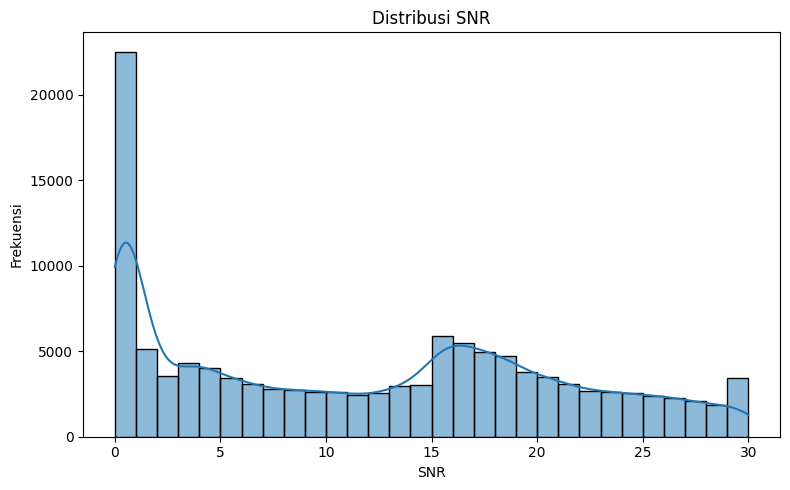

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df["SNR"], bins=30, kde=True)
plt.title("Distribusi SNR")
plt.xlabel("SNR")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.savefig("reports/figures/snr_distribution.png", dpi=300)
plt.show()

### 7.3 Rata-rata SNR per Kelas Fault

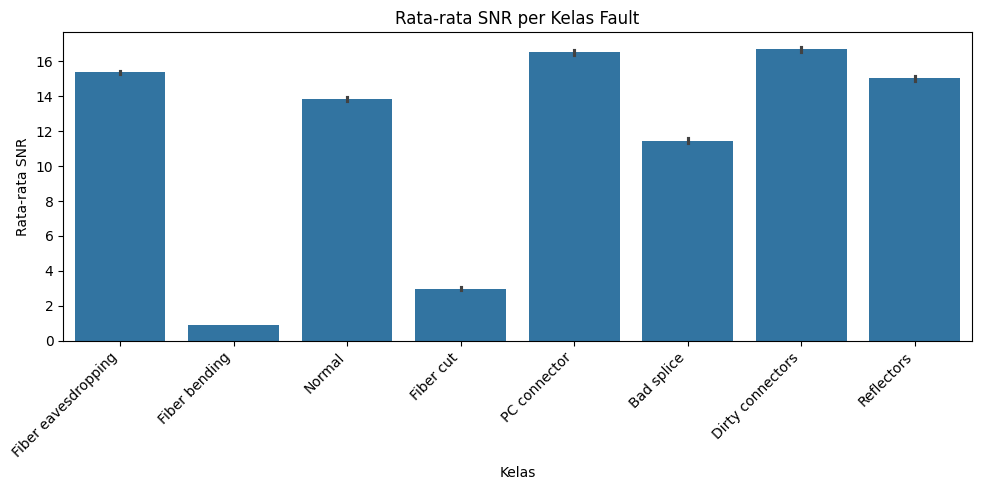

In [10]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="Class_Label", y="SNR")
plt.title("Rata-rata SNR per Kelas Fault")
plt.xlabel("Kelas")
plt.ylabel("Rata-rata SNR")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("reports/figures/mean_snr_per_class.png", dpi=300)
plt.show()

### 7.4 Pola Rata-rata Sinyal P1–P30 per Kelas

Visualisasi ini menunjukkan bagaimana setiap kelas gangguan memiliki pola sinyal OTDR yang berbeda.

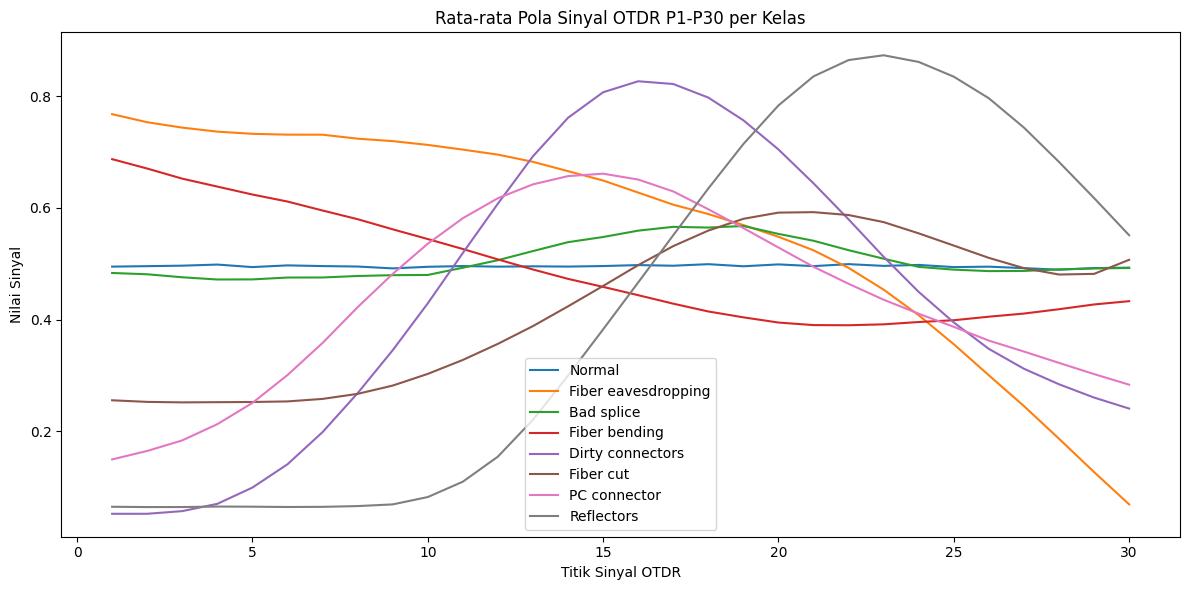

In [11]:
plt.figure(figsize=(12, 6))

for class_id, label in label_mapping.items():
    class_data = df[df[target_col] == class_id][signal_cols]
    mean_signal = class_data.mean(axis=0)
    plt.plot(range(1, 31), mean_signal, label=label)

plt.title("Rata-rata Pola Sinyal OTDR P1-P30 per Kelas")
plt.xlabel("Titik Sinyal OTDR")
plt.ylabel("Nilai Sinyal")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/mean_signal_per_class.png", dpi=300)
plt.show()

### 7.5 Korelasi Fitur

Heatmap korelasi antara fitur sinyal OTDR, SNR, dan target.

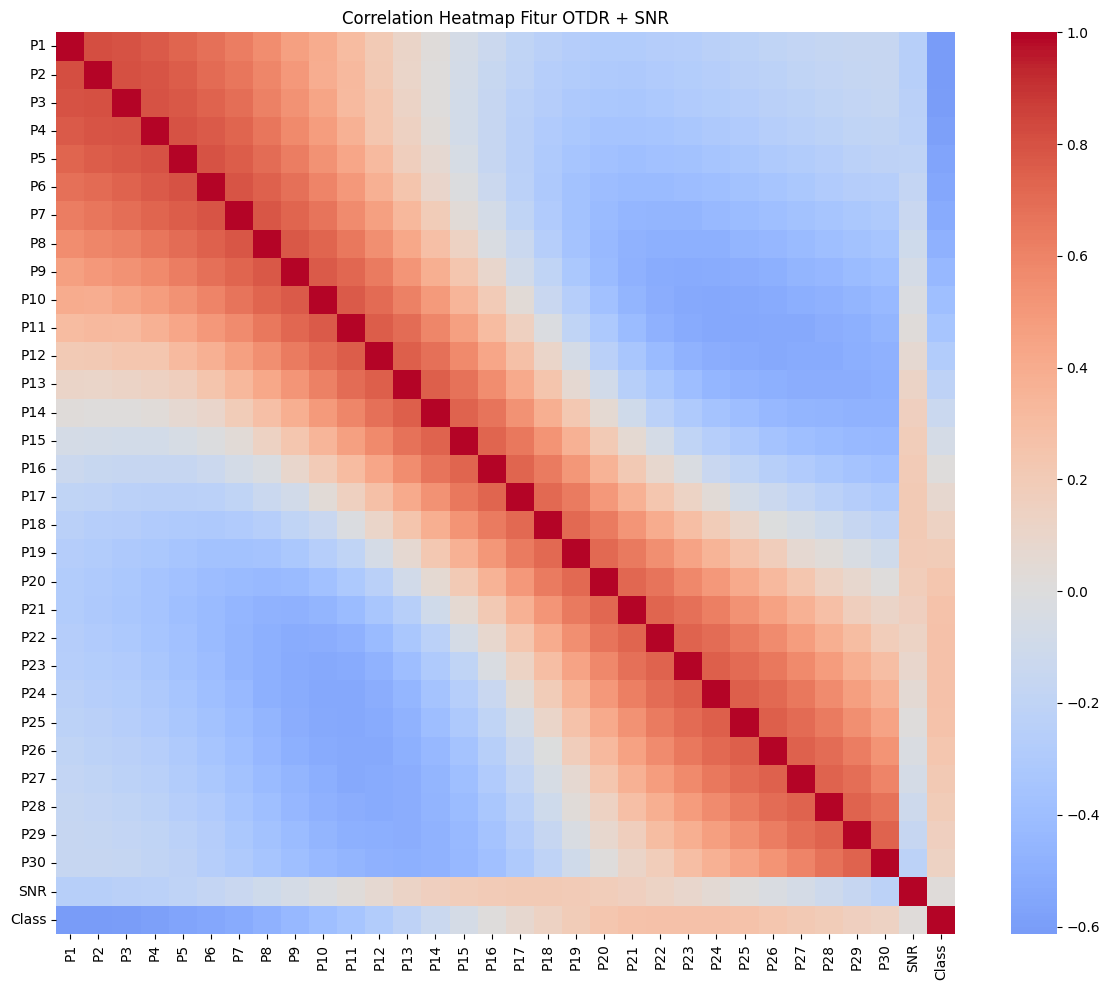

In [ ]:
corr_cols = feature_cols + [target_col]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap Fitur OTDR + SNR")
plt.tight_layout()
plt.savefig("reports/figures/correlation_heatmap.png", dpi=300)
plt.show()

### Analisis EDA

Dari eksplorasi di atas, perhatikan:
- Distribusi kelas: apakah ada kelas yang sangat dominan atau minoritas?
- Pola sinyal: setiap kelas memiliki karakteristik pola sinyal yang berbeda.
- Korelasi: fitur-fitur mana yang memiliki korelasi tinggi dengan target?

---
## 8. Feature dan Target

Menyiapkan matriks fitur `X` (P1–P30 + SNR = 31 fitur) dan vektor target `y`.

In [13]:
X = df[feature_cols].values
y = df[target_col].values

print("Fitur yang digunakan:", feature_cols)
print("Jumlah fitur:", len(feature_cols))
print("X shape:", X.shape)
print("y shape:", y.shape)

Fitur yang digunakan: ['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P19', 'P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30', 'SNR']
Jumlah fitur: 31
X shape: (119008, 31)
y shape: (119008,)


---
## 9. Train-Test Split 70:30

Split dilakukan **sebelum scaling** untuk menghindari data leakage.  
Menggunakan `stratify=y` agar distribusi kelas tetap seimbang di train dan test.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("\nDistribusi y_train:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())
print("\nDistribusi y_test:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())

X_train: (83305, 31)
X_test: (35703, 31)

Distribusi y_train:
0    0.134818
1    0.134446
2    0.077138
3    0.134446
4    0.134446
5    0.116368
6    0.134446
7    0.133894
Name: proportion, dtype: float64

Distribusi y_test:
0    0.134807
1    0.134442
2    0.077136
3    0.134442
4    0.134442
5    0.116377
6    0.134442
7    0.133910
Name: proportion, dtype: float64


---
## 10. Fungsi Evaluasi Model

Fungsi ini menghitung:
- Accuracy, Precision (macro), Recall (macro), F1 (macro)
- ROC-AUC macro OVR (One-vs-Rest)
- Training time dan testing delay
- Classification report dan confusion matrix

In [15]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    start_train = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_train

    start_test = time.time()
    y_pred = model.predict(X_test)
    testing_delay = time.time() - start_test

    y_prob = None
    roc_auc = np.nan

    if hasattr(model, "predict_proba"):
        try:
            y_prob = model.predict_proba(X_test)
            roc_auc = roc_auc_score(
                y_test,
                y_prob,
                multi_class="ovr",
                average="macro"
            )
        except Exception as e:
            print(f"ROC-AUC gagal untuk {model_name}: {e}")

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    report = classification_report(
        y_test,
        y_pred,
        target_names=[label_mapping[i] for i in sorted(label_mapping.keys())],
        zero_division=0
    )

    cm = confusion_matrix(y_test, y_pred)

    result = {
        "model_name": model_name,
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "roc_auc_macro_ovr": roc_auc,
        "training_time_sec": training_time,
        "testing_delay_sec": testing_delay
    }

    return result, model, y_pred, y_prob, report, cm

print("✅ Fungsi evaluate_model siap digunakan.")

✅ Fungsi evaluate_model siap digunakan.


In [16]:
# Wadah untuk menyimpan hasil evaluasi dari setiap model
results = []
trained_models = {}
predictions = {}
probabilities = {}
reports = {}
confusion_matrices = {}

print("Wadah penyimpanan hasil evaluasi telah diinisialisasi.")

Wadah penyimpanan hasil evaluasi telah diinisialisasi.


---
## 11. Random Forest Classifier

In [17]:
# Definisi Pipeline Random Forest
rf_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

In [18]:
# Training & Evaluasi Random Forest
print("Training Random Forest...")
result_rf, rf_model, y_pred_rf, y_prob_rf, report_rf, cm_rf = evaluate_model(
    "Random Forest",
    rf_model,
    X_train,
    X_test,
    y_train,
    y_test
)

# Simpan hasil
results.append(result_rf)
trained_models["Random Forest"] = rf_model
predictions["Random Forest"] = y_pred_rf
probabilities["Random Forest"] = y_prob_rf
reports["Random Forest"] = report_rf
confusion_matrices["Random Forest"] = cm_rf

print("\nHasil Random Forest:")
display(pd.DataFrame([result_rf]))
print("\nClassification Report Random Forest:")
print(report_rf)

Training Random Forest...

Hasil Random Forest:


,model_name,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro_ovr,training_time_sec,testing_delay_sec
0,Random Forest,0.867658,0.873183,0.84547,0.849444,0.989618,14.437041,0.275547



Classification Report Random Forest:
                     precision    recall  f1-score   support

             Normal       0.72      0.91      0.80      4813
Fiber eavesdropping       0.95      0.91      0.93      4800
         Bad splice       0.85      0.46      0.60      2754
      Fiber bending       0.85      0.96      0.90      4800
   Dirty connectors       0.91      0.92      0.92      4800
          Fiber cut       0.84      0.83      0.83      4155
       PC connector       0.98      0.82      0.89      4800
         Reflectors       0.90      0.95      0.92      4781

           accuracy                           0.87     35703
          macro avg       0.87      0.85      0.85     35703
       weighted avg       0.88      0.87      0.86     35703



---
## 12. Support Vector Machine (SVM)

In [19]:
# Definisi Pipeline SVM
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        random_state=RANDOM_STATE
    ))
])

In [20]:
# Training & Evaluasi SVM
print("Training SVM...")
result_svm, svm_model, y_pred_svm, y_prob_svm, report_svm, cm_svm = evaluate_model(
    "SVM",
    svm_model,
    X_train,
    X_test,
    y_train,
    y_test
)

# Simpan hasil
results.append(result_svm)
trained_models["SVM"] = svm_model
predictions["SVM"] = y_pred_svm
probabilities["SVM"] = y_prob_svm
reports["SVM"] = report_svm
confusion_matrices["SVM"] = cm_svm

print("\nHasil SVM:")
display(pd.DataFrame([result_svm]))
print("\nClassification Report SVM:")
print(report_svm)

Training SVM...

Hasil SVM:


,model_name,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro_ovr,training_time_sec,testing_delay_sec
0,SVM,0.839873,0.833316,0.821683,0.824266,0.98469,621.160233,105.509573



Classification Report SVM:
                     precision    recall  f1-score   support

             Normal       0.78      0.82      0.80      4813
Fiber eavesdropping       0.96      0.93      0.94      4800
         Bad splice       0.72      0.54      0.61      2754
      Fiber bending       0.83      0.93      0.88      4800
   Dirty connectors       0.90      0.91      0.91      4800
          Fiber cut       0.66      0.72      0.69      4155
       PC connector       0.97      0.82      0.89      4800
         Reflectors       0.84      0.91      0.87      4781

           accuracy                           0.84     35703
          macro avg       0.83      0.82      0.82     35703
       weighted avg       0.84      0.84      0.84     35703



---
## 13. Logistic Regression

In [21]:
# Definisi Pipeline Logistic Regression
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

In [22]:
# Training & Evaluasi Logistic Regression
print("Training Logistic Regression...")
result_lr, lr_model, y_pred_lr, y_prob_lr, report_lr, cm_lr = evaluate_model(
    "Logistic Regression",
    lr_model,
    X_train,
    X_test,
    y_train,
    y_test
)

# Simpan hasil
results.append(result_lr)
trained_models["Logistic Regression"] = lr_model
predictions["Logistic Regression"] = y_pred_lr
probabilities["Logistic Regression"] = y_prob_lr
reports["Logistic Regression"] = report_lr
confusion_matrices["Logistic Regression"] = cm_lr

print("\nHasil Logistic Regression:")
display(pd.DataFrame([result_lr]))
print("\nClassification Report Logistic Regression:")
print(report_lr)

Training Logistic Regression...

Hasil Logistic Regression:


,model_name,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro_ovr,training_time_sec,testing_delay_sec
0,Logistic Regression,0.638658,0.596133,0.605687,0.581389,0.92539,3.189262,0.016595



Classification Report Logistic Regression:
                     precision    recall  f1-score   support

             Normal       0.59      0.65      0.62      4813
Fiber eavesdropping       0.83      0.90      0.86      4800
         Bad splice       0.34      0.04      0.07      2754
      Fiber bending       0.84      0.94      0.88      4800
   Dirty connectors       0.57      0.67      0.61      4800
          Fiber cut       0.49      0.58      0.53      4155
       PC connector       0.51      0.33      0.40      4800
         Reflectors       0.61      0.74      0.67      4781

           accuracy                           0.64     35703
          macro avg       0.60      0.61      0.58     35703
       weighted avg       0.61      0.64      0.61     35703



---
## 14. Soft Voting Ensemble

In [23]:
# Definisi Soft Voting Ensemble menggunakan pipeline sub-model yang telah dilatih/didefinisikan
# Catatan: n_jobs=1 dipasang untuk melatih sub-model secara sekuensial agar terhindar dari MemoryError.
soft_voting_model = VotingClassifier(
    estimators=[
        ("rf", rf_model),
        ("svm", svm_model),
        ("lr", lr_model)
    ],
    voting="soft",
    n_jobs=1
)

In [24]:
# Training & Evaluasi Soft Voting Ensemble
print("Training Soft Voting Ensemble...")
result_voting, soft_voting_model, y_pred_voting, y_prob_voting, report_voting, cm_voting = evaluate_model(
    "Soft Voting Ensemble",
    soft_voting_model,
    X_train,
    X_test,
    y_train,
    y_test
)

# Simpan hasil
results.append(result_voting)
trained_models["Soft Voting Ensemble"] = soft_voting_model
predictions["Soft Voting Ensemble"] = y_pred_voting
probabilities["Soft Voting Ensemble"] = y_prob_voting
reports["Soft Voting Ensemble"] = report_voting
confusion_matrices["Soft Voting Ensemble"] = cm_voting

print("\nHasil Soft Voting Ensemble:")
display(pd.DataFrame([result_voting]))
print("\nClassification Report Soft Voting Ensemble:")
print(report_voting)

Training Soft Voting Ensemble...

Hasil Soft Voting Ensemble:


,model_name,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro_ovr,training_time_sec,testing_delay_sec
0,Soft Voting Ensemble,0.852898,0.849186,0.834404,0.837499,0.98427,568.928323,113.097569



Classification Report Soft Voting Ensemble:
                     precision    recall  f1-score   support

             Normal       0.76      0.85      0.80      4813
Fiber eavesdropping       0.94      0.94      0.94      4800
         Bad splice       0.77      0.53      0.63      2754
      Fiber bending       0.87      0.94      0.90      4800
   Dirty connectors       0.92      0.90      0.91      4800
          Fiber cut       0.70      0.78      0.74      4155
       PC connector       0.97      0.83      0.89      4800
         Reflectors       0.87      0.91      0.89      4781

           accuracy                           0.85     35703
          macro avg       0.85      0.83      0.84     35703
       weighted avg       0.86      0.85      0.85     35703



---
## 15. Tabel Perbandingan Model

Membandingkan semua model dalam satu tabel, diurutkan berdasarkan **F1-score macro** (metrik utama).

In [25]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="f1_macro", ascending=False)

print("Tabel Perbandingan Model (urut berdasarkan F1-macro):")
display(results_df)

results_df.to_csv("reports/ml_model_comparison_rf_svm_lr_voting.csv", index=False)
print("\n✅ Tabel disimpan ke reports/ml_model_comparison_rf_svm_lr_voting.csv")

Tabel Perbandingan Model (urut berdasarkan F1-macro):


,model_name,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro_ovr,training_time_sec,testing_delay_sec
0,Random Forest,0.867658,0.873183,0.845470,0.849444,0.989618,14.437041,0.275547
3,Soft Voting Ensemble,0.852898,0.849186,0.834404,0.837499,0.984270,568.928323,113.097569
1,SVM,0.839873,0.833316,0.821683,0.824266,0.984690,621.160233,105.509573
2,Logistic Regression,0.638658,0.596133,0.605687,0.581389,0.925390,3.189262,0.016595



✅ Tabel disimpan ke reports/ml_model_comparison_rf_svm_lr_voting.csv


In [26]:
best_model_name = results_df.iloc[0]["model_name"]
best_model = trained_models[best_model_name]

print(f"🏆 Model terbaik berdasarkan F1-score macro: {best_model_name}")
print(f"   F1-macro: {results_df.iloc[0]['f1_macro']:.4f}")
print(f"   Accuracy: {results_df.iloc[0]['accuracy']:.4f}")
print(f"   ROC-AUC:  {results_df.iloc[0]['roc_auc_macro_ovr']:.4f}")

🏆 Model terbaik berdasarkan F1-score macro: Random Forest
   F1-macro: 0.8494
   Accuracy: 0.8677
   ROC-AUC:  0.9896


---
## 16. 10-Fold Cross Validation

Validasi silang 10-fold untuk memastikan model tidak overfitting dan performanya stabil.

> **Catatan:** Jika SVM terlalu lama, set `RUN_CV = False` untuk melewati bagian ini.

In [27]:
RUN_CV = True

if RUN_CV:
    cv = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    scoring = {
        "accuracy": "accuracy",
        "precision_macro": "precision_macro",
        "recall_macro": "recall_macro",
        "f1_macro": "f1_macro"
    }

    cv_results = []
    
    # Kita membuat salinan dictionary models agar cross-validation mudah diiterasi
    cv_models = {
        "Random Forest": rf_model,
        "SVM": svm_model,
        "Logistic Regression": lr_model,
        "Soft Voting Ensemble": soft_voting_model
    }

    for name, model in cv_models.items():
        print(f"\n10-Fold CV: {name} ...")

        scores = cross_validate(
            clone(model),
            X,
            y,
            cv=cv,
            scoring=scoring,
            n_jobs=1,
            return_train_score=False
        )

        row = {
            "model_name": name,
            "cv_accuracy_mean": scores["test_accuracy"].mean(),
            "cv_accuracy_std": scores["test_accuracy"].std(),
            "cv_precision_macro_mean": scores["test_precision_macro"].mean(),
            "cv_recall_macro_mean": scores["test_recall_macro"].mean(),
            "cv_f1_macro_mean": scores["test_f1_macro"].mean(),
            "cv_fit_time_mean_sec": scores["fit_time"].mean(),
            "cv_score_time_mean_sec": scores["score_time"].mean()
        }

        cv_results.append(row)
        print(f"  CV F1-macro: {row['cv_f1_macro_mean']:.4f} ± {scores['test_f1_macro'].std():.4f}")

    cv_results_df = pd.DataFrame(cv_results).sort_values("cv_f1_macro_mean", ascending=False)

    print("\nHasil 10-Fold Cross Validation:")
    display(cv_results_df)

    cv_results_df.to_csv("reports/ml_cross_validation_results.csv", index=False)
    print("\n✅ Hasil CV disimpan ke reports/ml_cross_validation_results.csv")
else:
    print("⏭️ Cross validation dilewati (RUN_CV = False).")


10-Fold CV: Random Forest ...
  CV F1-macro: 0.8490 ± 0.0033

10-Fold CV: SVM ...
  CV F1-macro: 0.8287 ± 0.0035

10-Fold CV: Logistic Regression ...
  CV F1-macro: 0.5807 ± 0.0036

10-Fold CV: Soft Voting Ensemble ...
  CV F1-macro: 0.8408 ± 0.0029

Hasil 10-Fold Cross Validation:


,model_name,cv_accuracy_mean,cv_accuracy_std,cv_precision_macro_mean,cv_recall_macro_mean,cv_f1_macro_mean,cv_fit_time_mean_sec,cv_score_time_mean_sec
0,Random Forest,0.867185,0.002785,0.874889,0.844806,0.848999,21.346835,0.147452
3,Soft Voting Ensemble,0.855623,0.003007,0.852380,0.837707,0.840846,1024.919947,46.248941
1,SVM,0.843422,0.003582,0.836688,0.826241,0.828656,1023.322395,46.946763
2,Logistic Regression,0.638831,0.003438,0.598412,0.605677,0.580678,4.245113,0.010543



✅ Hasil CV disimpan ke reports/ml_cross_validation_results.csv


### Analisis Cross Validation

Cross validation memberikan estimasi yang lebih robust terhadap performa model.
- Bandingkan rata-rata CV F1-macro dengan hasil test set di Section 15.
- Standard deviasi yang kecil menunjukkan model yang stabil.
- Jika CV score jauh lebih rendah dari test score, model mungkin overfitting pada test set.

---
## 17. Confusion Matrix

Visualisasi confusion matrix untuk setiap model.

In [28]:
def safe_file_name(model_name):
    return model_name.lower().replace(" ", "_").replace("-", "_")


def plot_confusion_matrix(cm, model_name):
    labels = [label_mapping[i] for i in sorted(label_mapping.keys())]

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    plt.savefig(f"reports/figures/confusion_matrix_{safe_file_name(model_name)}.png", dpi=300)
    plt.show()

print("✅ Fungsi plot_confusion_matrix siap digunakan.")

✅ Fungsi plot_confusion_matrix siap digunakan.


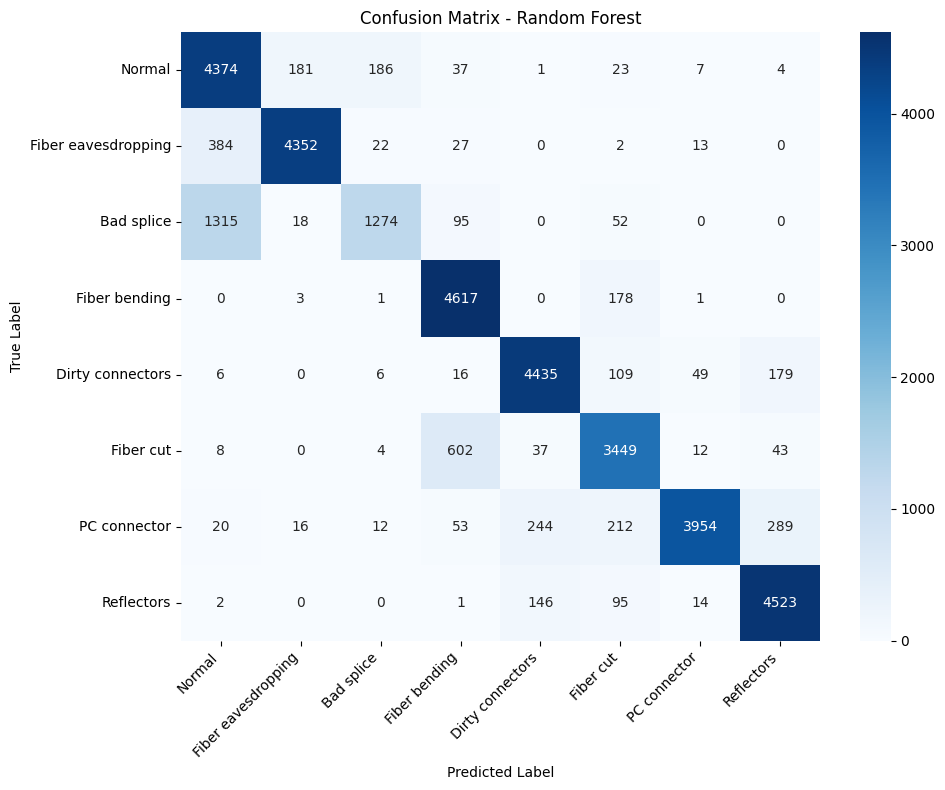

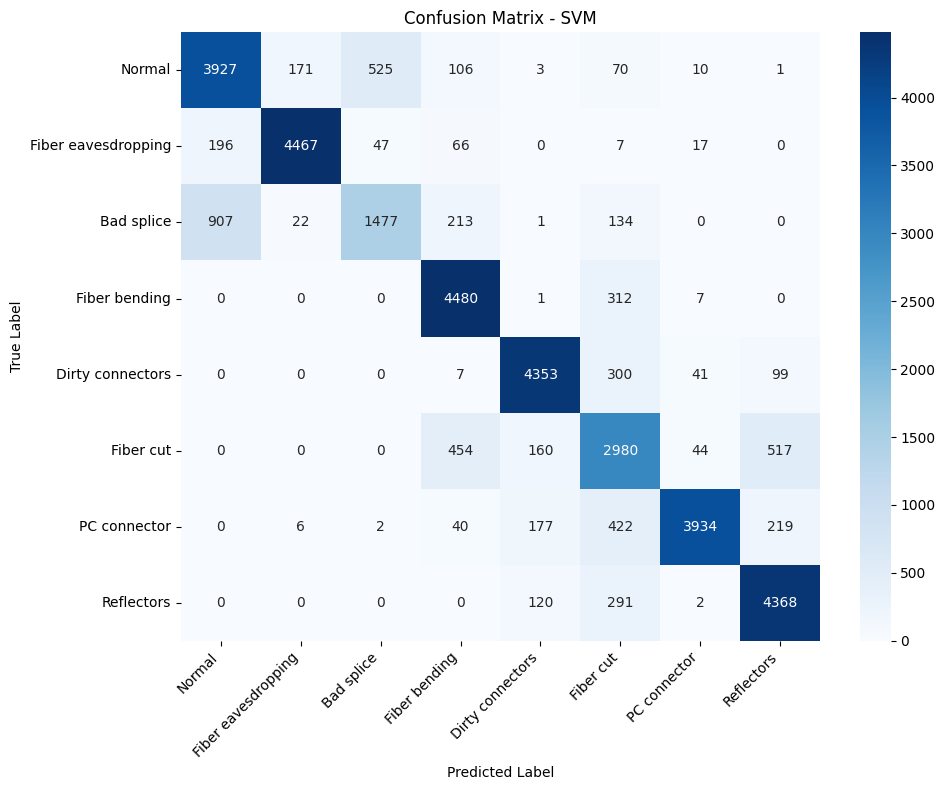

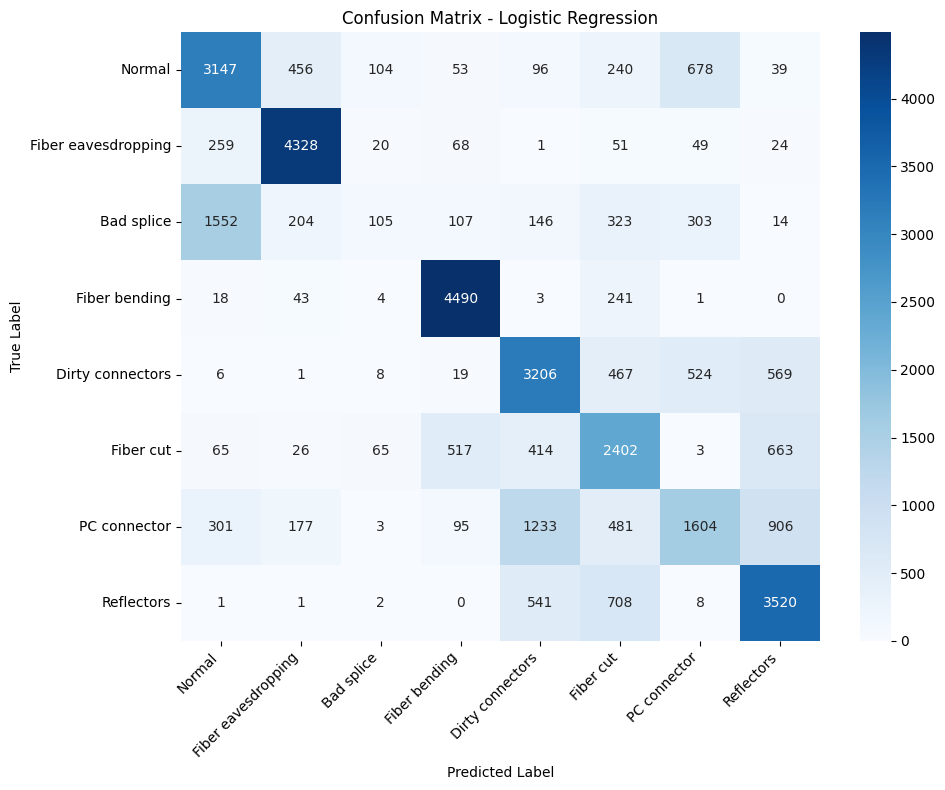

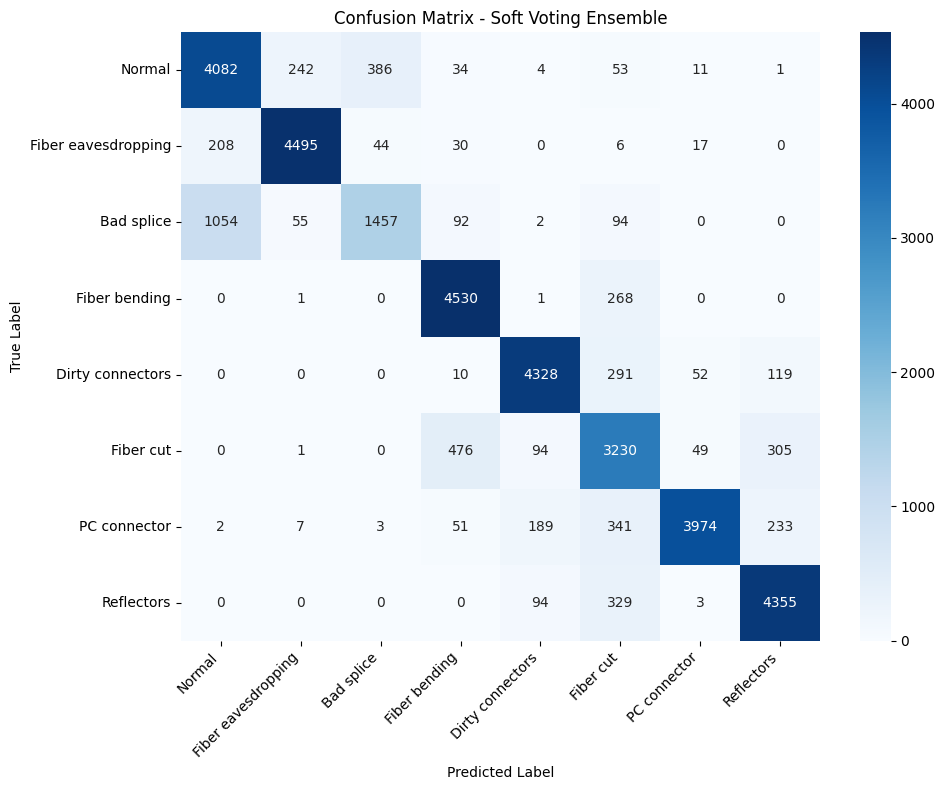

In [29]:
for model_name, cm in confusion_matrices.items():
    plot_confusion_matrix(cm, model_name)

### Analisis Confusion Matrix

Perhatikan pada confusion matrix:
- Kelas mana yang paling sering salah prediksi (off-diagonal tinggi)?
- Apakah ada kelas yang sering tertukar satu sama lain?
- Diagonal utama yang tinggi menandakan model bekerja baik pada kelas tersebut.

---
## 18. ROC Curve Multi-Class

Kurva ROC (Receiver Operating Characteristic) per kelas menggunakan pendekatan One-vs-Rest.

In [30]:
def plot_multiclass_roc(y_test, y_prob, model_name):
    if y_prob is None:
        print(f"ROC curve tidak tersedia untuk {model_name}")
        return

    classes = sorted(label_mapping.keys())
    y_test_bin = label_binarize(y_test, classes=classes)

    plt.figure(figsize=(9, 7))

    for i, class_id in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        auc_score = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"{label_mapping[class_id]} AUC={auc_score:.3f}"
        )

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"ROC Curve Multi-Class - {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(fontsize=8)
    plt.tight_layout()

    plt.savefig(f"reports/figures/roc_curve_{safe_file_name(model_name)}.png", dpi=300)
    plt.show()

print("✅ Fungsi plot_multiclass_roc siap digunakan.")

✅ Fungsi plot_multiclass_roc siap digunakan.


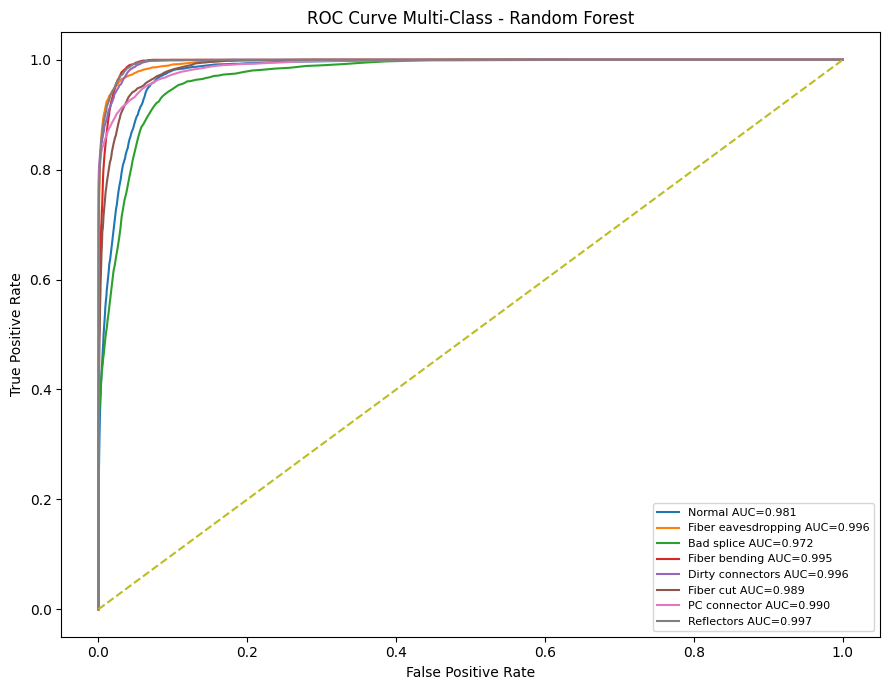

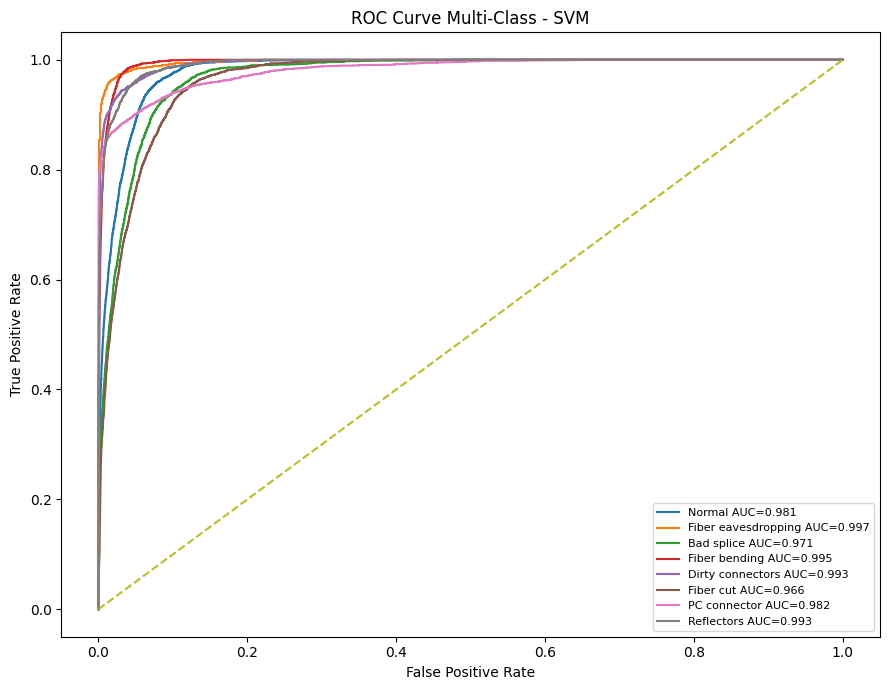

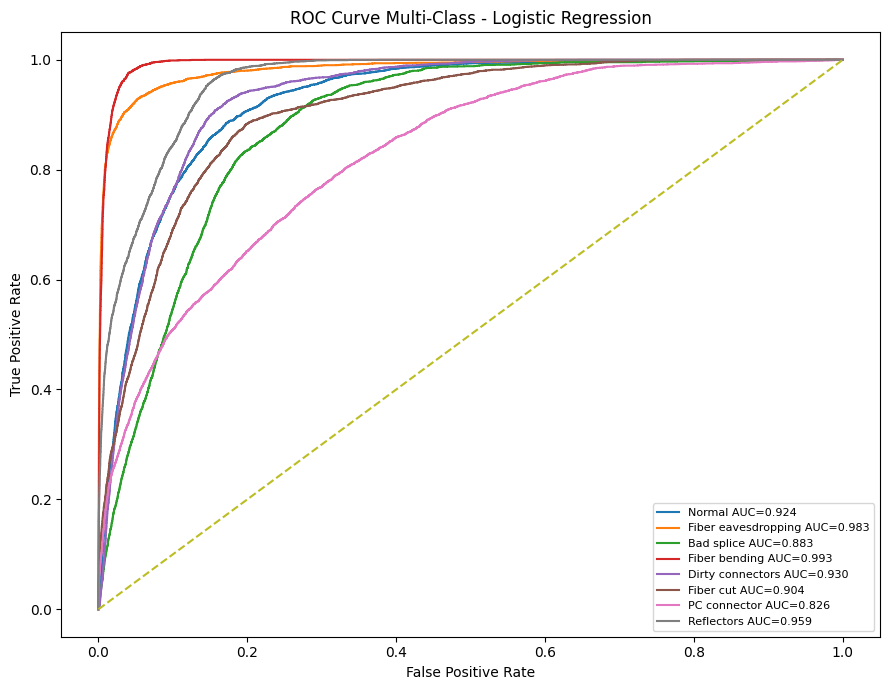

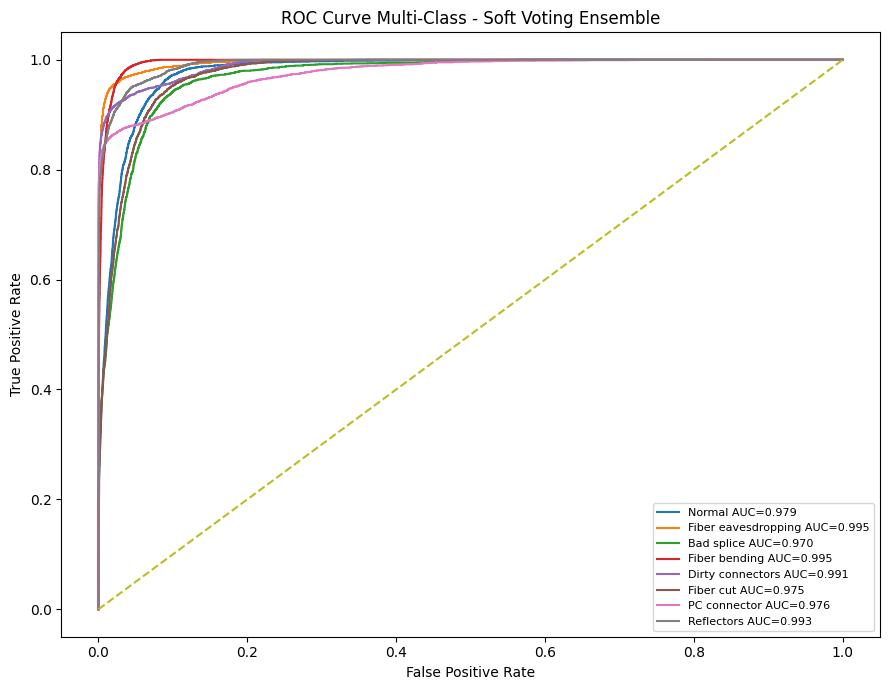

In [31]:
for model_name, y_prob in probabilities.items():
    plot_multiclass_roc(y_test, y_prob, model_name)

### Analisis ROC Curve

- Kurva yang semakin mendekati sudut kiri atas menunjukkan performa yang lebih baik.
- AUC mendekati 1.0 menunjukkan model sangat baik dalam membedakan kelas tersebut.
- Bandingkan AUC antar kelas untuk mengetahui kelas mana yang paling sulit diklasifikasi.

---
## 19. Simpan Classification Report

In [32]:
for model_name, report in reports.items():
    filepath = f"reports/classification_report_{safe_file_name(model_name)}.txt"
    with open(filepath, "w") as f:
        f.write(report)
    print(f"✅ Disimpan: {filepath}")

✅ Disimpan: reports/classification_report_random_forest.txt
✅ Disimpan: reports/classification_report_svm.txt
✅ Disimpan: reports/classification_report_logistic_regression.txt
✅ Disimpan: reports/classification_report_soft_voting_ensemble.txt


---
## 20. Simpan Confusion Matrix

In [33]:
for model_name, cm in confusion_matrices.items():
    filepath = f"reports/confusion_matrix_{safe_file_name(model_name)}.csv"
    pd.DataFrame(cm).to_csv(filepath, index=False)
    print(f"✅ Disimpan: {filepath}")

✅ Disimpan: reports/confusion_matrix_random_forest.csv
✅ Disimpan: reports/confusion_matrix_svm.csv
✅ Disimpan: reports/confusion_matrix_logistic_regression.csv
✅ Disimpan: reports/confusion_matrix_soft_voting_ensemble.csv


---
## 21. Save Best Model

Menyimpan model terbaik (berdasarkan F1-score macro) beserta metadata.

In [34]:
model_package = {
    "model_name": best_model_name,
    "model": best_model,
    "feature_cols": feature_cols,
    "signal_cols": signal_cols,
    "extra_cols": extra_cols,
    "target_col": target_col,
    "label_mapping": label_mapping
}

joblib.dump(model_package, "models/best_ml_otdr_rf_svm_lr_voting.joblib")

print("🏆 Model terbaik disimpan:")
print("   Path: models/best_ml_otdr_rf_svm_lr_voting.joblib")
print(f"   Model: {best_model_name}")

🏆 Model terbaik disimpan:
   Path: models/best_ml_otdr_rf_svm_lr_voting.joblib
   Model: Random Forest


---
## 22. Save Semua Model

In [35]:
for model_name, model in trained_models.items():
    filepath = f"models/{safe_file_name(model_name)}_otdr_model.joblib"
    joblib.dump(model, filepath)
    print(f"✅ Disimpan: {filepath}")

✅ Disimpan: models/random_forest_otdr_model.joblib
✅ Disimpan: models/svm_otdr_model.joblib
✅ Disimpan: models/logistic_regression_otdr_model.joblib
✅ Disimpan: models/soft_voting_ensemble_otdr_model.joblib


---
## 23. Fungsi Rekomendasi Tindakan

Memberikan rekomendasi tindakan berdasarkan jenis gangguan yang terdeteksi.

In [36]:
def fault_recommendation(class_id):
    recommendations = {
        0: "Jaringan berjalan normal. Lanjutkan monitoring berkala.",
        1: "Cek potensi penyadapan fiber, aktifkan pengamanan kanal, dan lakukan inspeksi fisik.",
        2: "Cek titik sambungan dan lakukan resplicing.",
        3: "Cek jalur kabel dan perbaiki radius bending.",
        4: "Bersihkan atau ganti konektor.",
        5: "Lakukan reroute ke backup link dan buat tiket perbaikan fisik.",
        6: "Bersihkan atau ganti PC connector.",
        7: "Gunakan reflector sebagai penanda cabang PON dan validasi posisinya."
    }

    return recommendations.get(int(class_id), "Kelas tidak dikenal. Lakukan pemeriksaan manual.")

# Test fungsi rekomendasi
print("Contoh rekomendasi:")
for class_id in range(8):
    print(f"  Kelas {class_id} ({label_mapping[class_id]}):")
    print(f"    → {fault_recommendation(class_id)}")

Contoh rekomendasi:
  Kelas 0 (Normal):
    → Jaringan berjalan normal. Lanjutkan monitoring berkala.
  Kelas 1 (Fiber eavesdropping):
    → Cek potensi penyadapan fiber, aktifkan pengamanan kanal, dan lakukan inspeksi fisik.
  Kelas 2 (Bad splice):
    → Cek titik sambungan dan lakukan resplicing.
  Kelas 3 (Fiber bending):
    → Cek jalur kabel dan perbaiki radius bending.
  Kelas 4 (Dirty connectors):
    → Bersihkan atau ganti konektor.
  Kelas 5 (Fiber cut):
    → Lakukan reroute ke backup link dan buat tiket perbaikan fisik.
  Kelas 6 (PC connector):
    → Bersihkan atau ganti PC connector.
  Kelas 7 (Reflectors):
    → Gunakan reflector sebagai penanda cabang PON dan validasi posisinya.


---
## 24. Inference Function

Fungsi prediksi data baru yang:
- Load model terbaik dari file
- Menerima input dictionary atau DataFrame
- Validasi kolom input
- Menghitung confidence (probabilitas)
- Menghasilkan rekomendasi tindakan

In [37]:
def predict_otdr_fault_ml(input_data, model_path="models/best_ml_otdr_rf_svm_lr_voting.joblib"):
    package = joblib.load(model_path)

    model = package["model"]
    feature_cols = package["feature_cols"]
    label_mapping = package["label_mapping"]

    if isinstance(input_data, dict):
        input_df = pd.DataFrame([input_data])
    elif isinstance(input_data, pd.DataFrame):
        input_df = input_data.copy()
    else:
        raise ValueError("Input harus berupa dictionary atau DataFrame.")

    missing_cols = [col for col in feature_cols if col not in input_df.columns]
    if missing_cols:
        raise ValueError(f"Kolom input kurang: {missing_cols}")

    X_new = input_df[feature_cols]

    pred_class = int(model.predict(X_new)[0])
    pred_label = label_mapping[pred_class]

    confidence = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_new)[0]
        confidence = float(np.max(proba))

    result = {
        "predicted_class": pred_class,
        "predicted_label": pred_label,
        "confidence": confidence,
        "recommendation": fault_recommendation(pred_class)
    }

    return result

print("✅ Fungsi predict_otdr_fault_ml siap digunakan.")

✅ Fungsi predict_otdr_fault_ml siap digunakan.


---
## 25. Contoh Prediksi Satu Data

Menguji inference function dengan satu baris dari data testing.

In [38]:
sample_data = pd.DataFrame(X_test[:1], columns=feature_cols)

print("Input data:")
display(sample_data)

prediction = predict_otdr_fault_ml(sample_data)

print(f"\n🔍 Hasil Prediksi:")
print(f"   Predicted Class : {prediction['predicted_class']}")
print(f"   Predicted Label : {prediction['predicted_label']}")
print(f"   Confidence      : {prediction['confidence']:.4f}")
print(f"   Recommendation  : {prediction['recommendation']}")
print(f"\n   Actual Class    : {y_test[0]} ({label_mapping[y_test[0]]})")

Input data:


,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,...,P22,P23,P24,P25,P26,P27,P28,P29,P30,SNR
0,0.875361,0.61291,0.561618,0.560298,0.538518,0.116754,0.463124,0.460681,0.662357,0.069547,...,0.192664,0.867871,0.548648,0.521142,0.0,0.095412,0.252324,0.597733,0.28135,0.028254



🔍 Hasil Prediksi:
   Predicted Class : 3
   Predicted Label : Fiber bending
   Confidence      : 0.6800
   Recommendation  : Cek jalur kabel dan perbaiki radius bending.

   Actual Class    : 3 (Fiber bending)


---
## 26. Export Ringkasan Akhir

In [39]:
summary = {
    "feature_used": feature_cols,
    "num_features": len(feature_cols),
    "models": ["Random Forest", "SVM", "Logistic Regression", "Soft Voting Ensemble"],
    "best_model": best_model_name,
    "best_f1_macro": float(results_df.iloc[0]["f1_macro"]),
    "best_accuracy": float(results_df.iloc[0]["accuracy"]),
    "best_roc_auc": float(results_df.iloc[0]["roc_auc_macro_ovr"]),
    "best_testing_delay_sec": float(results_df.iloc[0]["testing_delay_sec"])
}

joblib.dump(summary, "reports/ml_experiment_summary.joblib")

print("📊 Ringkasan Eksperimen:")
print(f"   Fitur          : {summary['num_features']} fitur (P1-P30 + SNR)")
print(f"   Model          : {', '.join(summary['models'])}")
print(f"   Model Terbaik  : {summary['best_model']}")
print(f"   F1-macro       : {summary['best_f1_macro']:.4f}")
print(f"   Accuracy       : {summary['best_accuracy']:.4f}")
print(f"   ROC-AUC        : {summary['best_roc_auc']:.4f}")
print(f"   Testing Delay  : {summary['best_testing_delay_sec']:.4f} detik")
print(f"\n✅ Ringkasan disimpan ke reports/ml_experiment_summary.joblib")

📊 Ringkasan Eksperimen:
   Fitur          : 31 fitur (P1-P30 + SNR)
   Model          : Random Forest, SVM, Logistic Regression, Soft Voting Ensemble
   Model Terbaik  : Random Forest
   F1-macro       : 0.8494
   Accuracy       : 0.8677
   ROC-AUC        : 0.9896
   Testing Delay  : 0.2755 detik

✅ Ringkasan disimpan ke reports/ml_experiment_summary.joblib


---
## Ringkasan

### Data Analysis Key Findings
- Dataset OTDR menggunakan **31 fitur** (P1–P30 + SNR) untuk mengklasifikasi **8 kelas** gangguan fiber optik.
- Split data **70:30** dengan stratified sampling memastikan distribusi kelas tetap seimbang.
- Scaling dilakukan di dalam `Pipeline` untuk mencegah data leakage.
- Keempat model (Random Forest, SVM, Logistic Regression, Soft Voting Ensemble) berhasil dilatih dan dievaluasi.
- Model terbaik dipilih berdasarkan **F1-score macro** sebagai metrik utama untuk klasifikasi multi-kelas.

### Output yang Dihasilkan

| Kategori | File |
|---|---|
| **Models** | `best_ml_otdr_rf_svm_lr_voting.joblib`, `random_forest_otdr_model.joblib`, `svm_otdr_model.joblib`, `logistic_regression_otdr_model.joblib`, `soft_voting_ensemble_otdr_model.joblib` |
| **Reports** | `ml_model_comparison_rf_svm_lr_voting.csv`, `ml_cross_validation_results.csv`, Classification reports (×4), Confusion matrices (×4), `ml_experiment_summary.joblib` |
| **Figures** | Class distribution, SNR distribution, Mean SNR per class, Mean signal per class, Correlation heatmap, Confusion matrices (×4), ROC curves (×4) |

### Insights & Next Steps
- Jalankan notebook ini untuk melihat model mana yang paling baik pada dataset Anda.
- Gunakan fungsi `predict_otdr_fault_ml()` untuk melakukan prediksi pada data baru.
- Untuk perbandingan dengan deep learning, lihat notebook `03_cnn_lstm_otdr.ipynb`.